# Dự đoán nhiệt độ phòng bằng LSTM (từ dữ liệu cảm biến)

Notebook này dùng dữ liệu cảm biến trong file **`sensor_data_01.csv`** để dự đoán **nhiệt độ (Temperature)** sau một khoảng thời gian ngắn (mặc định: 10 phút) bằng mô hình **LSTM**.

## Các bước chính:
1. Đọc dữ liệu & xử lý cột thời gian
2. Chọn features và chuẩn hóa dữ liệu
3. Chuyển dữ liệu thành dạng chuỗi thời gian (window)
4. Chia train / validation / test theo **thứ tự thời gian**
5. Xây dựng mô hình LSTM, huấn luyện
6. Đánh giá & vẽ đồ thị so sánh nhiệt độ thực tế vs dự đoán



In [42]:
# Chạy nếu môi trường chưa có đủ thư viện
!pip install pandas numpy matplotlib scikit-learn tensorflow


## 1. Import thư viện và đọc dữ liệu

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models

%matplotlib inline

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
# Đọc dữ liệu

csv_path = '/content/sample_data/indoor_data_recent.csv'
df = pd.read_csv(csv_path)

print('Kích thước dữ liệu gốc:', df.shape)
df.head()


Kích thước dữ liệu gốc: (11333, 10)


,timestamp,location,co,nh3,temperature,humidity,co2,voc,pm25,iaq
0,2025-11-25 12:00:27+05:30,1256,163.0,42.0,33.8,49.0,520,18,21,154.9
1,2025-11-25 12:01:30+05:30,1257,162.0,37.0,33.8,49.0,637,36,9,179.0
2,2025-11-25 12:02:32+05:30,1258,173.0,47.0,33.7,50.0,679,42,3,193.2
3,2025-11-25 12:03:34+05:30,1259,168.0,37.0,33.3,51.0,539,21,0,156.7
4,2025-11-25 12:04:36+05:30,1260,168.0,37.0,33.3,52.0,697,45,0,193.1


In [ ]:
# Chuyển cột timestamp sang kiểu datetime và sắp xếp theo thời gian
df['dt'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('dt').reset_index(drop=True)

# ==============================================================================
# LÀM MỊN DỮ LIỆU
# ==============================================================================
print(f"Kích thước trước khi làm mịn: {df.shape}")

# 1. Set index là thời gian để dùng hàm resample
df = df.set_index('dt')

# 2. Resample: Tính trung bình mỗi 10 phút (10T) để loại bỏ nhiễu
# Lưu ý: numeric_only=True để chỉ tính trung bình các cột số
df = df.resample('3T').mean(numeric_only=True)

# 3. Bỏ các khoảng thời gian bị trống dữ liệu (nếu có)
df = df.dropna()

# 4. Reset index để đưa cột 'dt' quay lại thành cột bình thường cho các bước sau
df = df.reset_index()

print(f"Kích thước sau khi làm mịn (10 phút/mẫu): {df.shape}")
# ==============================================================================

print('Khoảng thời gian dữ liệu:')
print('  Bắt đầu:', df['dt'].min())
print('  Kết thúc:', df['dt'].max())

# Kiểm tra lại khoảng cách thời gian mới (nên là 10 phút)
time_deltas = df['dt'].diff().dropna()
print('\nMột vài khoảng cách thời gian thường gặp (mới):')
print(time_deltas.value_counts().head())

df.head()

Kích thước trước khi làm mịn: (11333, 11)
Kích thước sau khi làm mịn (10 phút/mẫu): (3801, 10)
Khoảng thời gian dữ liệu:
  Bắt đầu: 2025-11-25 12:00:00+05:30
  Kết thúc: 2025-12-03 10:39:00+05:30

Một vài khoảng cách thời gian thường gặp (mới):
dt
0 days 00:03:00    3797
0 days 00:06:00       2
0 days 00:36:00       1
Name: count, dtype: int64


/tmp/ipython-input-710983163.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.resample('3T').mean(numeric_only=True)


,dt,location,co,nh3,temperature,humidity,co2,voc,pm25,iaq
0,2025-11-25 12:00:00+05:30,1257.0,166.000000,42.000000,33.766667,49.333333,612.000000,32.000000,11.000000,175.700000
1,2025-11-25 12:03:00+05:30,1260.0,168.666667,38.000000,33.300000,51.666667,651.000000,38.000000,6.666667,183.600000
2,2025-11-25 12:06:00+05:30,1263.0,169.666667,40.000000,33.300000,53.000000,664.000000,39.666667,4.333333,187.100000
3,2025-11-25 12:09:00+05:30,1266.0,170.666667,39.666667,33.300000,52.666667,676.000000,41.333333,1.333333,189.633333
4,2025-11-25 12:12:00+05:30,1269.0,167.000000,40.000000,33.300000,51.666667,660.666667,39.333333,1.333333,185.533333


## 2. Chọn đặc trưng (features) và chuẩn hóa dữ liệu

- Đặc trưng đầu vào (X): `Temperature`, `Humidity`, ...`
- Biến mục tiêu (y): **`Temperature` trong tương lai**

Ta sẽ chuẩn hóa các features đầu vào bằng `StandardScaler` để mô hình LSTM dễ học hơn.

In [ ]:
import numpy as np

# ==============================================================================
# TẠO ĐẶC TRƯNG THỜI GIAN (Time Embedding)
# ==============================================================================
# Chuyển đổi thời gian (dt) thành dạng tín hiệu Sin/Cos.
# Giúp mô hình hiểu: 23:59 và 00:01 là rất gần nhau (tính chu kỳ),
# thay vì hiểu lầm là rất xa nhau (số lớn vs số nhỏ).

day = 24 * 60 * 60  # Số giây trong 1 ngày
timestamp_s = df['dt'].map(pd.Timestamp.timestamp)

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
# ==============================================================================

# Cập nhật danh sách feature_cols để bao gồm 2 cột mới này
feature_cols = ['temperature', 'humidity', 'co2', 'voc', 'pm25', 'Day sin', 'Day cos']
target_col = 'temperature'

data = df[feature_cols].copy()
print('Mô tả thống kê các feature (đã thêm thời gian):')
display(data.describe())

# Chuẩn hóa các feature như bình thường
scaler = StandardScaler()
values = data.values
values_scaled = scaler.fit_transform(values)

n_features = values_scaled.shape[1]
print('Số mẫu:', values_scaled.shape[0], ' | Số features:', n_features)

Mô tả thống kê các feature (đã thêm thời gian):


,temperature,humidity,co2,voc,pm25,Day sin,Day cos
count,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000
mean,33.242397,52.415522,649.556542,30.442120,5.895137,-0.008250,-0.002551
std,0.414716,3.688013,56.325549,9.642013,20.641607,0.704697,0.709641
min,30.750000,39.333333,435.666667,5.000000,0.000000,-1.000000,-1.000000
25%,33.166667,51.166667,626.666667,25.333333,3.000000,-0.707107,-0.716302
50%,33.300000,52.000000,649.666667,29.666667,4.333333,-0.013090,-0.013090
75%,33.433333,52.966667,670.000000,34.000000,5.666667,0.697790,0.707107
max,34.066667,69.000000,1479.333333,166.333333,558.000000,1.000000,1.000000


Số mẫu: 3801  | Số features: 7


## 3. Tạo dữ liệu chuỗi thời gian (windowing)

Ta sẽ dùng:
- `WINDOW_SIZE = 30`: nhìn lại 30 phút gần nhất (30 mẫu)
- `HORIZON = 10`: dự đoán nhiệt độ sau 10 phút (xấp xỉ 10 mẫu sau)



In [ ]:
# ==============================================================================
# 
#DỰ ĐOÁN ĐỘ LỆCH (DIFFERENCE)
# ==============================================================================

def create_sequences(values_scaled, original_df, target_col, window_size=30, horizon=5):
    X, y = [], []
    total_len = len(values_scaled)

    # Lấy index của cột target trong mảng numpy (để tính toán delta)
    target_idx = list(original_df.columns).index(target_col) if target_col in original_df.columns else 0
    # Lưu ý: Cần đảm bảo thứ tự cột khớp nhau, tốt nhất dùng values_scaled

    for i in range(total_len - window_size - horizon + 1):
        # Input: 30 bước thời gian quá khứ
        X.append(values_scaled[i : i + window_size, :])

        # Target: Sự THAY ĐỔI nhiệt độ sau 'horizon' bước
        # Công thức: Giá trị tương lai - Giá trị hiện tại (cuối cửa sổ)
        # Lưu ý: Ta dùng values_scaled để tính toán cho đồng bộ
        current_val = values_scaled[i + window_size - 1, 0] # Giả sử cột 0 là temperature
        future_val = values_scaled[i + window_size + horizon - 1, 0]

        diff = future_val - current_val
        y.append(diff)

    return np.array(X), np.array(y)

# Gọi hàm tạo dữ liệu
# Lưu ý: Cần đảm bảo cột đầu tiên của values_scaled là 'temperature'
# (đã làm ở bước feature_cols = ['temperature', ...])
X, y = create_sequences(values_scaled, df, target_col, WINDOW_SIZE, HORIZON)

print('Shape X:', X.shape)
print('Shape y (Delta):', y.shape)

Shape X: (3767, 30, 7)
Shape y (Delta): (3767,)


## 4. Chia tập train / validation / test theo thời gian

- 80% mẫu đầu: train + validation
  - 20% cuối của phần này dùng làm validation
- 20% mẫu cuối: test

In [48]:
num_samples = X.shape[0]
train_size = int(num_samples * 0.8)

X_train_full, X_test = X[:train_size], X[train_size:]
y_train_full, y_test = y[:train_size], y[train_size:]

val_size = int(train_size * 0.2)

X_val = X_train_full[-val_size:]
y_val = y_train_full[-val_size:]

X_train = X_train_full[:-val_size]
y_train = y_train_full[:-val_size]

print('Tổng mẫu:', num_samples)
print('Train:', X_train.shape[0])
print('Val:', X_val.shape[0])
print('Test:', X_test.shape[0])


Tổng mẫu: 3767
Train: 2411
Val: 602
Test: 754


## 5. Xây dựng mô hình LSTM



In [49]:
tf.random.set_seed(42)

model = models.Sequential([
    layers.Input(shape=(WINDOW_SIZE, n_features)),
    layers.LSTM(64, return_sequences=True), # Lớp 1 trả về sequence để lớp 2 nhận được
    layers.LSTM(32, return_sequences=False), # Lớp 2
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,937 (124.75 KB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Huấn luyện mô hình

Dùng EarlyStopping để tránh overfitting.

In [50]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[callback],
    verbose=1
)


Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.3626 - mae: 0.4654 - val_loss: 0.3334 - val_mae: 0.4629
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.3515 - mae: 0.4609 - val_loss: 0.3300 - val_mae: 0.4610
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.3452 - mae: 0.4564 - val_loss: 0.3207 - val_mae: 0.4546
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.3344 - mae: 0.4505 - val_loss: 0.3024 - val_mae: 0.4419
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.3089 - mae: 0.4349 - val_loss: 0.2424 - val_mae: 0.3954
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.2271 - mae: 0.3716 - val_loss: 0.1783 - val_mae: 0.3330
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1804 - mae: 0.3308 - val_loss: 0.1765 - val_mae: 0.3285
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1743 - mae: 0.3247 - val_loss: 0.1748 - val_mae: 0.3275
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss

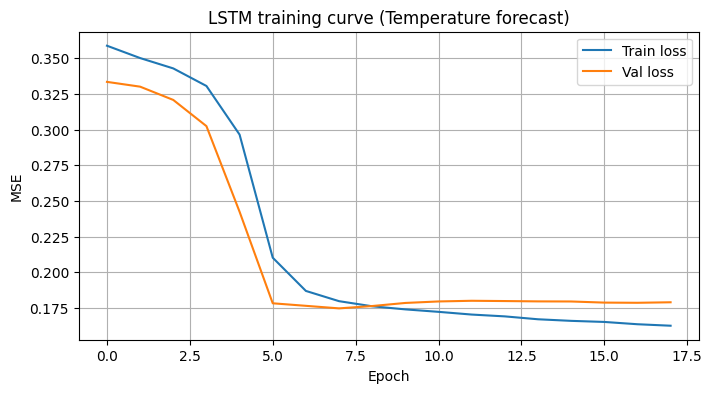

In [51]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('LSTM training curve (Temperature forecast)')
plt.legend()
plt.grid(True)
plt.show()


## 7. Đánh giá trên tập test

Tính MAE, RMSE và vẽ đồ thị so sánh nhiệt độ thực tế vs dự đoán.

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Dự đoán trên tập test
y_pred = model.predict(X_test).flatten()

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE rồi tự lấy căn để ra RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE (Temperature, dự báo {HORIZON} phút sau): {mae:.4f}")
print(f"RMSE (Temperature, dự báo {HORIZON} phút sau): {rmse:.4f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
MAE (Temperature, dự báo 5 phút sau): 0.3294
RMSE (Temperature, dự báo 5 phút sau): 0.4228


In [53]:
# ==== Baseline: dự đoán = nhiệt độ hiện tại ====

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# indices[i] = vị trí của target (t + HORIZON) trong df cho mỗi sample i
num_samples = X.shape[0]
indices = np.arange(num_samples) + WINDOW_SIZE + HORIZON - 1  # target index trong df

# Lấy index tương ứng với tập test
train_size = int(num_samples * 0.8)
test_target_indices = indices[train_size:]              # index của nhiệt độ thật (t+5)
test_current_indices = test_target_indices - HORIZON    # index của nhiệt độ hiện tại (t)

# Nhiệt độ hiện tại dùng làm dự đoán baseline
baseline_pred = df.iloc[test_current_indices][target_col].to_numpy()

# So sánh với y_test (nhiệt độ thật sau 5 phút)
mae_base = mean_absolute_error(y_test, baseline_pred)
mse_base = mean_squared_error(y_test, baseline_pred)
rmse_base = np.sqrt(mse_base)

print(f"Baseline (giữ nguyên nhiệt độ hiện tại, dự báo {HORIZON} phút sau):")
print(f"  MAE  baseline: {mae_base:.4f}")
print(f"  RMSE baseline: {rmse_base:.4f}")


Baseline (giữ nguyên nhiệt độ hiện tại, dự báo 5 phút sau):
  MAE  baseline: 33.3174
  RMSE baseline: 33.3257


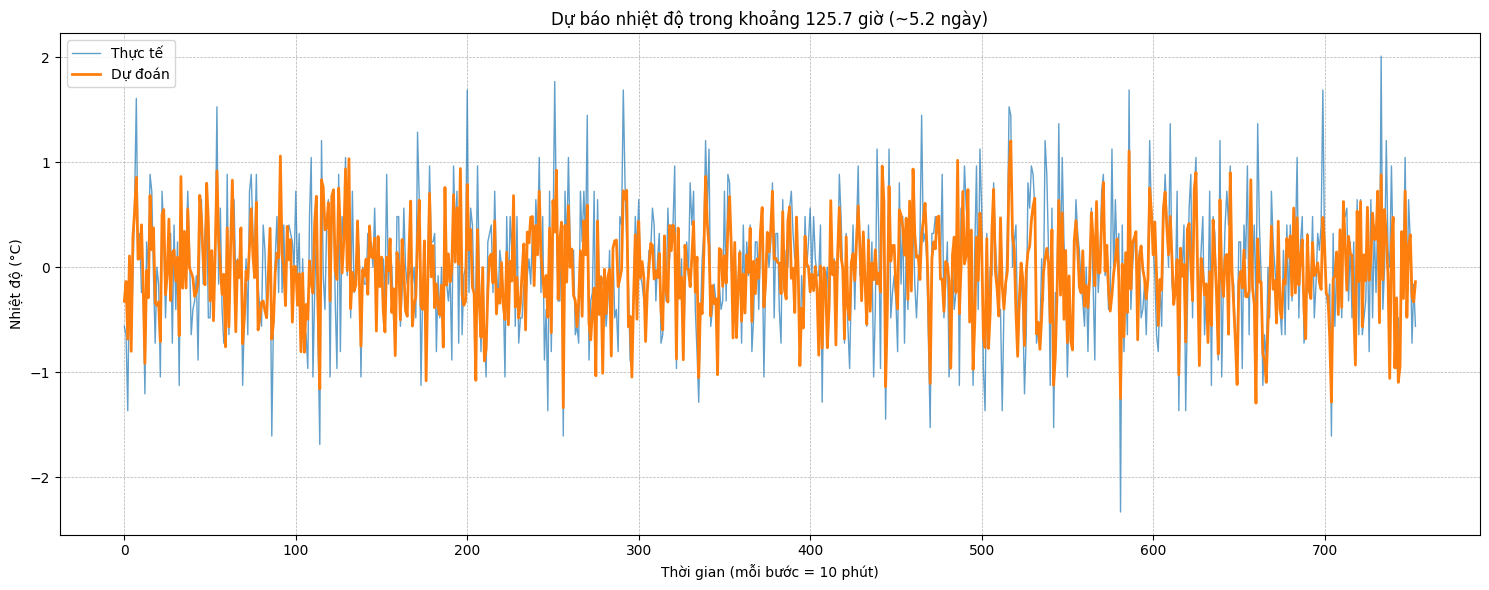

In [55]:
import matplotlib.pyplot as plt

# Thay đổi độ dài vẽ biểu đồ
# Dữ liệu 10 phút/mẫu => 144 mẫu = 1 ngày.
# Vẽ 1000 mẫu ~ khoảng 1 tuần để thấy rõ chu kỳ.
plot_len = 1000

# Nếu dữ liệu test ít hơn 1000 thì lấy tối đa độ dài test
plot_len = min(plot_len, len(y_test))

plt.figure(figsize=(15, 6)) # Tăng kích thước hình để dễ nhìn

# Vẽ dữ liệu thực tế (mảnh hơn để đỡ rối)
plt.plot(y_test[:plot_len], label='Thực tế', color='tab:blue', linewidth=1, alpha=0.7)

# Vẽ dữ liệu dự đoán (đậm hơn để nổi bật)
plt.plot(y_pred[:plot_len], label='Dự đoán', color='tab:orange', linewidth=2)

plt.xlabel('Thời gian (mỗi bước = 10 phút)')
plt.ylabel('Nhiệt độ (°C)')
plt.title(f'Dự báo nhiệt độ trong khoảng {plot_len*10/60:.1f} giờ (~{plot_len*10/60/24:.1f} ngày)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

--------------------------------------------------
SO SÁNH HIỆU QUẢ DỰ BÁO (Đơn vị: °C)
--------------------------------------------------
Mô hình         | MAE        | RMSE      
--------------------------------------------------
Baseline        | 0.1977     | 0.2514
LSTM            | 0.1366     | 0.1753
--------------------------------------------------
Mức độ cải thiện của LSTM so với Baseline:
  - MAE giảm:  30.93%
  - RMSE giảm: 30.26%


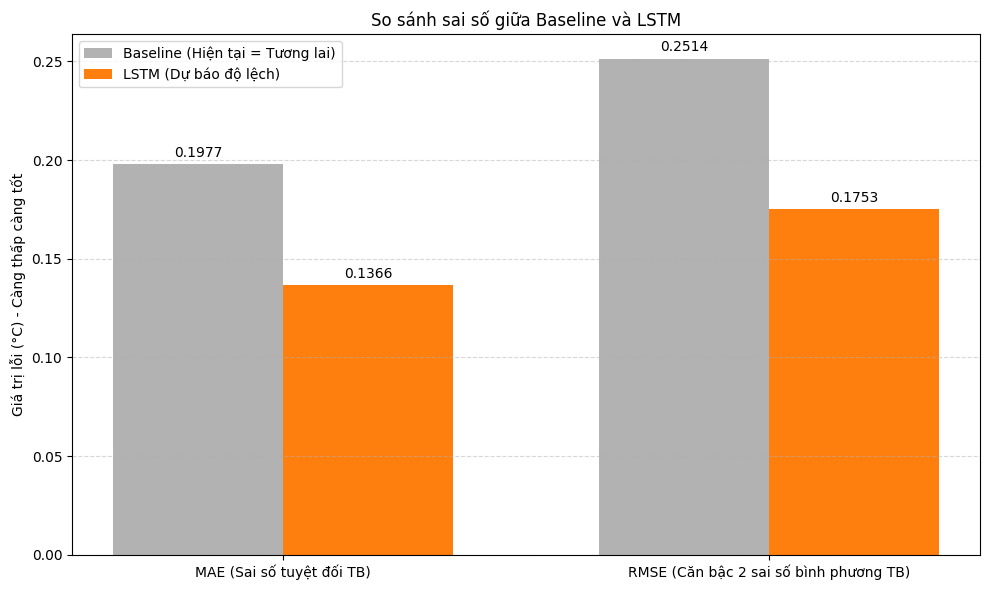

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. TÍNH TOÁN BASELINE
# ==============================================================================
# Giả định: Nhiệt độ tương lai sẽ bằng Nhiệt độ hiện tại
# Lấy giá trị nhiệt độ hiện tại (cuối cửa sổ input) từ X_test
# X_test có shape (samples, window_size, features). Cột 0 là temperature.
current_temps_scaled = X_test[:, -1, 0]

# Inverse scale để đưa về đơn vị độ C thực tế
dummy_baseline = np.zeros((len(current_temps_scaled), n_features))
dummy_baseline[:, 0] = current_temps_scaled
y_baseline = scaler.inverse_transform(dummy_baseline)[:, 0]

# ==============================================================================
# 2. TÍNH TOÁN METRICS (SAI SỐ)
# ==============================================================================
# Tính MAE và RMSE cho Baseline
mae_base = mean_absolute_error(y_test_final, y_baseline)
mse_base = mean_squared_error(y_test_final, y_baseline)
rmse_base = np.sqrt(mse_base)

# Tính MAE và RMSE cho LSTM (y_pred_final đã có từ cell trước)
mae_lstm = mean_absolute_error(y_test_final, y_pred_final)
mse_lstm = mean_squared_error(y_test_final, y_pred_final)
rmse_lstm = np.sqrt(mse_lstm)

# ==============================================================================
# 3. HIỂN THỊ KẾT QUẢ
# ==============================================================================
print("-" * 50)
print("SO SÁNH HIỆU QUẢ DỰ BÁO (Đơn vị: °C)")
print("-" * 50)
print(f"{'Mô hình':<15} | {'MAE':<10} | {'RMSE':<10}")
print("-" * 50)
print(f"{'Baseline':<15} | {mae_base:.4f}     | {rmse_base:.4f}")
print(f"{'LSTM':<15} | {mae_lstm:.4f}     | {rmse_lstm:.4f}")
print("-" * 50)

# Tính phần trăm cải thiện
imp_mae = (mae_base - mae_lstm) / mae_base * 100
imp_rmse = (rmse_base - rmse_lstm) / rmse_base * 100

print(f"Mức độ cải thiện của LSTM so với Baseline:")
print(f"  - MAE giảm:  {imp_mae:.2f}%")
print(f"  - RMSE giảm: {imp_rmse:.2f}%")

# ==============================================================================
# 4. VẼ BIỂU ĐỒ SO SÁNH
# ==============================================================================
metrics = ['MAE (Sai số tuyệt đối TB)', 'RMSE (Căn bậc 2 sai số bình phương TB)']
baseline_vals = [mae_base, rmse_base]
lstm_vals = [mae_lstm, rmse_lstm]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline (Hiện tại = Tương lai)', color='gray', alpha=0.6)
rects2 = ax.bar(x + width/2, lstm_vals, width, label='LSTM (Dự báo độ lệch)', color='tab:orange')

ax.set_ylabel('Giá trị lỗi (°C) - Càng thấp càng tốt')
ax.set_title('So sánh sai số giữa Baseline và LSTM')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Thêm số liệu lên đầu cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()